<a href="https://colab.research.google.com/github/Hasita-K/Hasita_Kode/blob/main/Kode_Hasita_A3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CAP 4611 &mdash; Assignment 3: Classification (Telco Customer Churn)
Make sure your file name is `yourlastname_firstname.ipynb`

`This jupyter notebook is prepared by "Hasita Kode".`


> Fill in all code cells and markdown discussion cells as instructed.

<font color='red'>Don't forget to submit the phase 1 pdf and then finally the google colab link with edit permissions enabled </font>

## A. Load Data and Perform Basic EDA [10 pts = 1 + 1 + 1 + 2 + 5]

### I. **Import libraries:** pandas, numpy, matplotlib (set `%matplotlib inline`), matplotlib's pyplot, seaborn, missingno, scipy's stats, sklearn. (1 pt)

In [ ]:
# Write your code here
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import missingno as msno
from scipy import stats
import sklearn

### II. Load the dataset and display the number of rows and columns. (1 pt)

In [ ]:
# Write your code here
df = pd.read_csv('telco_churn2.csv')

print({df.shape[0]})
print({df.shape[1]})

{7043}
{24}


### III. Display the first 5 and last 5 rows. (1 pt)

In [ ]:
# Write your code here
df.head(5)
df.tail(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Education,SupportTicketID,ActiveCountryCode,Churn
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,One year,Yes,Mailed check,84.80,1990.5,NaN,TK-7F7A3F,1,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,NaN,TK-FA986E,1,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,Month-to-month,Yes,Electronic check,29.60,346.45,NaN,TK-9E7DB0,1,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,Month-to-month,Yes,Mailed check,74.40,306.6,NaN,TK-26F9B2,1,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,...,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,NaN,TK-21C059,1,No


### IV. Show how many columns contain null values. (2 pts)

In [ ]:
# Write your code here
null_columns = df.isnull().sum()
null_columns = null_columns[null_columns > 0]
print(len(null_columns))
print(null_columns)

1
Education    5679
dtype: int64


### V. Plot the target (`Churn`) distribution. In a markdown cell, discuss the class imbalance, what issues it may cause in your models, and propose at least one solution. (5 pts)

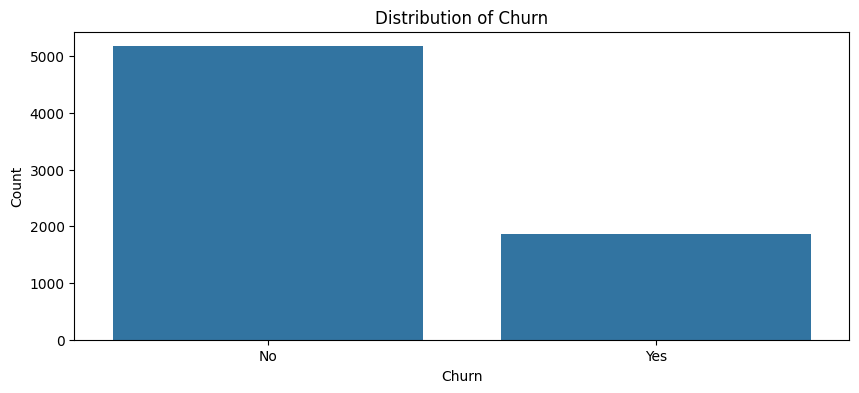

In [ ]:
# Write your code here
plt.figure(figsize=(10, 4))
ax = sns.countplot(x='Churn', data=df)
plt.title('Distribution of Churn')
plt.xlabel("Churn")
plt.ylabel("Count")

plt.show()

The target variable is imbalanced. It can cause the model to favor predicting the Majority classs (no) without actually learning the
patterns. As a result, accuracy alone can be misleading since the model will perform poorly in identifying the Yes class. You can use
SMOTE to oversample churn cases or by underssampling the majority class*Write your answer here.*

## B. Feature Selection and Pre-processing [32 pts]

### I. Drop identifier and constant columns (4 pts)
Look at the number of unique values in `customerID`, `SupportTicketID`, and `ActiveCountryCode`. Two of them are essentially unique per row and one is constant for every row. In a markdown cell, explain why each one carries no predictive value, then drop all three. Show sample rows to verify.

In [ ]:
# Write your code here
for col in ['customerID', 'SupportTicketID', 'ActiveCountryCode']:
  print(f"{col}: {df[col].nunique()}")

df = df.drop(columns=['customerID', 'SupportTicketID', 'ActiveCountryCode'])

print(df.columns.tolist())

customerID: 7043
SupportTicketID: 7042
ActiveCountryCode: 1
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Education', 'Churn']


The columns custoemrID and SupportTicketID were removed because they are unique identifiers that simply label each customer or
support ticket and do not contain any meaningful information about customer behavior. Including these columns would cause a model to
memorize individual records instead of learning patters. The activeCountryCode was also something I droped since it's the same
throughou

### II. Clean the TotalCharges column (4 pts)
`TotalCharges` is stored as text because a few rows are blank. Show that it is stored as text and how many blanks exist, convert it to numeric, then handle the resulting missing values (these rows correspond to brand new customers). Confirm the column is now numeric.

In [ ]:
# Write your code here
print(df['TotalCharges'].dtype)
df['TotalCharges'].head(10)

blank_count = (df['TotalCharges'].str.strip() == '').sum()
print(blank_count)

object
11


### III. Education level (4 pts = 1 + 2 + 1)

#### 1. Show the unique values of `Education`. (1 pt)

In [ ]:
# Write your code here
df['Education'].unique()

array([nan, 'Associate Degree', 'High School Graduate',
       "Bachelor's Degree", "Master's Degree"], dtype=object)

#### 2. Convert `Education` to ordinal values (High School Graduate → 0, Associate Degree → 1, Bachelor’s Degree → 2, Master’s Degree → 3). This column has many missing values, so decide how to handle them and, in a markdown cell, justify your choice. (2 pts)

In [ ]:
# Write your code here
education_mapping = {
    'High School Graduate' : 0,
    'Associate Degree' : 1,
    "Bachelor's Degree" : 2,
    "Master's Degree" : 3
}

df['Education'] = df['Education'].map(education_mapping)

print(f"Percent missing in education: {df['Education'].isnull().mean() * 100}")


Percent missing in education: 80.63325287519523


Since it's more than 60% I'm just going to drop it since I don't think anything else would be an option that won't cause a lot of bias*Write your answer here.*

#### 3. Show sample rows to verify the change. (1 pt)

In [ ]:
# Write your code here
df = df.drop(columns=['Education'])
df.sample(10)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
968,Female,0,No,No,71,Yes,No,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),77.35,5550.1,No
97,Male,0,No,No,5,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,21.05,113.85,Yes
6487,Female,0,Yes,No,61,Yes,Yes,Fiber optic,No,Yes,No,Yes,No,Yes,Two year,Yes,Bank transfer (automatic),94.35,5703,No
3740,Female,0,Yes,Yes,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,71.65,135.75,No
6708,Female,1,No,No,14,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,74.30,1096.25,Yes
4461,Male,0,No,No,29,Yes,No,Fiber optic,No,No,No,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,94.20,2607.6,No
3624,Female,1,Yes,Yes,62,Yes,Yes,Fiber optic,No,Yes,Yes,No,No,Yes,Month-to-month,Yes,Credit card (automatic),96.10,6019.35,No
1473,Female,0,No,No,24,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.75,2407.3,Yes
1119,Male,0,Yes,Yes,70,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,Yes,Two year,No,Bank transfer (automatic),59.50,4144.8,No
1446,Male,0,No,Yes,1,Yes,Yes,DSL,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,50.05,50.05,No


### IV. Contract column (4 pts = 1 + 2 + 1)

#### 1. Show the unique values of `Contract`. (1 pt)

In [ ]:
# Write your code here
df['Contract'].unique()

array(['Month-to-month', 'One year', 'Two year'], dtype=object)

#### 2. Convert `Contract` to ordinal values based on contract length (Month-to-month → 0, One year → 1, Two year → 2). (2 pts)

In [ ]:
# Write your code here
contract_mapping = {
    'Month-to-month' : 0,
    'One year' : 1,
    'Two year' : 2
}

df['Contract'] = df['Contract'].map(contract_mapping)

#### 3. Show the updated unique values. (1 pt)

In [ ]:
# Write your code here
df['Contract'].unique()

array([0, 1, 2])

### V. Other columns (8 pts = 2 + 4 + 1 + 1)

#### 1. Show the unique values of the remaining nominal columns: `gender`, `Partner`, `Dependents`, `PhoneService`, `MultipleLines`, `InternetService`, `OnlineSecurity`, `OnlineBackup`, `DeviceProtection`, `TechSupport`, `StreamingTV`, `StreamingMovies`, `PaperlessBilling`, `PaymentMethod`. Storing them in a list and looping is an easy approach. (2 pts)

In [ ]:
# Write your code here
nominal_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
                'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                'TechSupport', 'StreamingTV', 'StreamingMovies', 'PaperlessBilling',
                'PaymentMethod']

for col in nominal_cols:
  print(f"{col}: {df[col].unique()}")


gender: ['Female' 'Male']
Partner: ['Yes' 'No']
Dependents: ['No' 'Yes']
PhoneService: ['No' 'Yes']
MultipleLines: ['No phone service' 'No' 'Yes']
InternetService: ['DSL' 'Fiber optic' 'No']
OnlineSecurity: ['No' 'Yes' 'No internet service']
OnlineBackup: ['Yes' 'No' 'No internet service']
DeviceProtection: ['No' 'Yes' 'No internet service']
TechSupport: ['No' 'Yes' 'No internet service']
StreamingTV: ['No' 'Yes' 'No internet service']
StreamingMovies: ['No' 'Yes' 'No internet service']
PaperlessBilling: ['Yes' 'No']
PaymentMethod: ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']


#### 2. Use pandas’ `get_dummies` to create binary columns for those nominal columns. (4 pts)

In [ ]:
# Write your code here
df = pd.get_dummies(df, columns=nominal_cols, drop_first=True)
print(df.shape)

(7043, 30)


#### 3. In a markdown cell, write a short paragraph on the difference between `get_dummies` and `OneHotEncoder`. (1 pt)

get_dumies can create inconsitent columns between training and test data. OneHotEncoder learns the categories from the training data
and applies the same encoding to new data, amking it a better choice

#### 4. Show the first 5 and last 5 rows, and show the shape of the table. (1 pt)

In [ ]:
# Write your code here
print(df.head(5))
print(df.tail(5))

   SeniorCitizen  tenure  Contract  MonthlyCharges TotalCharges Churn  \
0              0       1         0           29.85        29.85    No   
1              0      34         1           56.95       1889.5    No   
2              0       2         0           53.85       108.15   Yes   
3              0      45         1           42.30      1840.75    No   
4              0       2         0           70.70       151.65   Yes   

   gender_Male  Partner_Yes  Dependents_Yes  PhoneService_Yes  ...  \
0        False         True           False             False  ...   
1         True        False           False              True  ...   
2         True        False           False              True  ...   
3         True        False           False             False  ...   
4        False        False           False              True  ...   

   TechSupport_No internet service  TechSupport_Yes  \
0                            False            False   
1                            F

### VI. Encode the target (2 pts)
Convert `Churn` to 1 and 0. Confirm there are no leftover identifier or duplicate raw columns (the columns replaced by `get_dummies` should no longer appear in raw form).

In [ ]:
# Write your code here
df['Churn'] = df['Churn'].map({'Yes' : 1, 'No' : 0})
print(df['Churn'].value_counts())
print(df['Churn'].dtype)

Churn
0    5174
1    1869
Name: count, dtype: int64
int64


In [ ]:
identifier_cols = ['customerID', 'SupportTicketID', 'ActiveCountryCode']
raw_nominal_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
                    'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                    'TechSupport', 'StreamingTV', 'StreamingMovies', 'PaperlessBilling',
                    'PaymentMethod']

leftover = [col for col in identifier_cols + raw_nominal_cols if col in df.columns]
print(f"Leftover raw/identifier columns: {leftover}")

Leftover raw/identifier columns: []


### VII. Feature scaling (5 pts = 2.5 + 2.5)

#### 1. Use `sklearn.preprocessing.MinMaxScaler` to scale all columns. (2.5 pts)

In [ ]:
# Write your code here
from sklearn.preprocessing import MinMaxScaler
import pandas as pd

if 'TotalCharges' in df.columns:
  df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors = 'coerce')
  df['TotalCharges'] = df['TotalCharges'].fillna(0)

scaler = MinMaxScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df), columns=df.columns, index=df.index)
df_scaled.head()

,SeniorCitizen,tenure,Contract,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,...,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0.0,0.013889,0.0,0.115423,0.003437,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
1,0.0,0.472222,0.5,0.385075,0.217564,0.0,1.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,0.0,0.027778,0.0,0.354229,0.012453,1.0,1.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
3,0.0,0.625000,0.5,0.239303,0.211951,0.0,1.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.027778,0.0,0.521891,0.017462,1.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0


#### 2. Show some scaled records. (2.5 pts)

In [ ]:
# Write your code here
df_scaled.head(5)

,SeniorCitizen,tenure,Contract,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,...,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0.0,0.013889,0.0,0.115423,0.003437,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
1,0.0,0.472222,0.5,0.385075,0.217564,0.0,1.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,0.0,0.027778,0.0,0.354229,0.012453,1.0,1.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
3,0.0,0.625000,0.5,0.239303,0.211951,0.0,1.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.027778,0.0,0.521891,0.017462,1.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0


### VIII. Move the target (1 pt)
Move the `Churn` column to the last position of the DataFrame and show that it has changed.

In [ ]:
# Write your code here
cols = [col for col in df_scaled.columns if col != 'Churn'] + ['Churn']
df_scaled = df_scaled[cols]

df_scaled.head()

,SeniorCitizen,tenure,Contract,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Churn
0,0.0,0.013889,0.0,0.115423,0.003437,0.0,1.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
1,0.0,0.472222,0.5,0.385075,0.217564,1.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,0.0,0.027778,0.0,0.354229,0.012453,1.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0
3,0.0,0.625000,0.5,0.239303,0.211951,1.0,0.0,0.0,0.0,1.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.027778,0.0,0.521891,0.017462,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0


## C. X/Y and Training/Test Split with Stratified Sampling and SMOTE [15 pts = 2 + 1.5 + 4 + 1.5 + 4 + 2]

### I. Copy all features into X and the target into Y. (2 pts)

In [ ]:
# Write your code here
X = df_scaled.drop(columns=['Churn']).copy()
Y = df_scaled['Churn'].copy()

### II. Show the ratio of 1 and 0 in Y. (1.5 pts)

In [ ]:
# Write your code here
print(Y.value_counts())
print(Y.value_counts(normalize=True))

Churn
0.0    5174
1.0    1869
Name: count, dtype: int64
Churn
0.0    0.73463
1.0    0.26537
Name: proportion, dtype: float64


### III. Use sklearn’s `train_test_split` to split the data into training and test sets. The test set should contain 30% of the instances and you must use `random_state = 0`. Use the `stratify` parameter so the class ratio is preserved in both sets. (4 pts)

In [ ]:
# Write your code here
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.3, random_state = 0, stratify=Y)

### IV. Show the ratio of 1 and 0 in y_train and then y_test. (1.5 pts)

In [ ]:
# Write your code here
print(Y_train.value_counts(normalize=True))
print(Y_test.value_counts(normalize=True))

Churn
0.0    0.734686
1.0    0.265314
Name: proportion, dtype: float64
Churn
0.0    0.734501
1.0    0.265499
Name: proportion, dtype: float64


### V. Use imblearn’s SMOTE to balance X_train. Keep a copy of the unbalanced training set; you will need it in later sections. (Helpful link: https://imbalanced-learn.org/stable/over_sampling.html, section 2.1.2) (4 pts)

In [ ]:
# Write your code here
from imblearn.over_sampling import SMOTE
from collections import Counter
X_train_unbalanced = X_train.copy()
Y_train_unbalanced = Y_train.copy()
smote = SMOTE(random_state=0)
X_train_balanced, Y_train_balanced = smote.fit_resample(X_train, Y_train)

### VI. Show the ratio of 0 and 1 in the rebalanced training set. Consider, do you now have 50% of each class? (2 pts)

In [ ]:
# Write your code here
print(Y_train_balanced.value_counts())
print(Y_train_balanced.value_counts(normalize=True))

Churn
1.0    3622
0.0    3622
Name: count, dtype: int64
Churn
1.0    0.5
0.0    0.5
Name: proportion, dtype: float64


## D. PCA and Logistic Regression [20 pts = 7 + 4 + 2 + 2 + 2 + 3]

### I. Build a pipeline to determine how many PCA components give the best logistic regression model, using the balanced training set. The number of components should range up to the maximum number of features you have. Produce a plot and in a markdown cell decide how many components to keep. (7 pts)
You can follow this link: https://machinelearningmastery.com/principal-components-analysis-for-dimensionality-reduction-in-python/ (consider using the code right before the plot).

In [ ]:
# Write your code here
from numpy import mean
from numpy import std
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression

def get_models(max_components):
  models = dict()
  for i in range(1, max_components + 1):
    steps = [('pca', PCA(n_components=i)), ('m', LogisticRegression())]
    models[str(i)] = Pipeline(steps = steps)
  return models

def evaluate_model(model, X, y):
  cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)
  scores = cross_val_score(model, X, y, scoring='accuracy', cv=cv, n_jobs=-1, error_score='raise')
  return scores

max_components = X_train_balanced.shape[1]

models = get_models(max_components)

results, names = list(), list()
for name, model in models.items():
  scores = evaluate_model(model, X_train_balanced, Y_train_balanced)
  results.append(scores)
  names.append(name)
  print('>%s %.3f (%.3f)' % (name, mean(scores), std(scores)))

>1 0.591 (0.016)
>2 0.750 (0.018)
>3 0.757 (0.019)
>4 0.758 (0.019)
>5 0.758 (0.018)
>6 0.758 (0.019)
>7 0.758 (0.017)
>8 0.763 (0.016)
>9 0.762 (0.017)
>10 0.763 (0.015)
>11 0.765 (0.015)
>12 0.764 (0.015)
>13 0.763 (0.016)
>14 0.763 (0.016)
>15 0.763 (0.015)
>16 0.764 (0.016)
>17 0.769 (0.016)
>18 0.774 (0.015)
>19 0.774 (0.015)
>20 0.777 (0.015)
>21 0.780 (0.016)
>22 0.780 (0.016)
>23 0.780 (0.016)
>24 0.780 (0.016)
>25 0.780 (0.016)
>26 0.780 (0.016)
>27 0.780 (0.016)
>28 0.780 (0.016)
>29 0.780 (0.016)


/tmp/ipykernel_1705/1787282910.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(results, labels=names, showmeans=True)


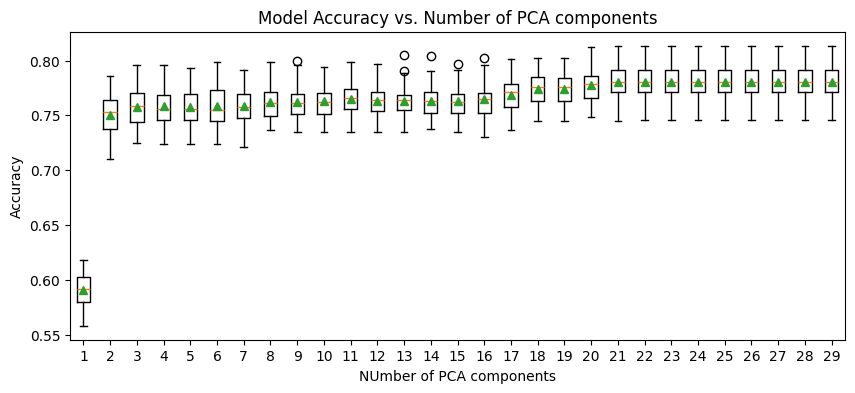

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
plt.boxplot(results, labels=names, showmeans=True)
plt.xlabel('NUmber of PCA components')
plt.ylabel('Accuracy')
plt.title("Model Accuracy vs. Number of PCA components")
plt.show()

The boxplot shows that accuracy improves as more PCA components are added, but levels off aroudn 20 components. After that point,
adding more provides no improvement while increasing the model complexity. so 20 components is a good choice

### II. Based on the chosen number of components, evaluate accuracy on the test set using `accuracy_score`. (4 pts)

In [ ]:
# Write your code here
from sklearn.metrics import accuracy_score

final_pipeline = Pipeline(steps=[
('pca', PCA(n_components=20)),
('m', LogisticRegression())
])

final_pipeline.fit(X_train_balanced, Y_train_balanced)

Y_pred = final_pipeline.predict(X_test)
test_accuracy = accuracy_score(Y_test, Y_pred)
print(test_accuracy)


0.7520113582584004


### III. Show the confusion matrix, and in a markdown cell, interpret the numbers you see. (2 pts)

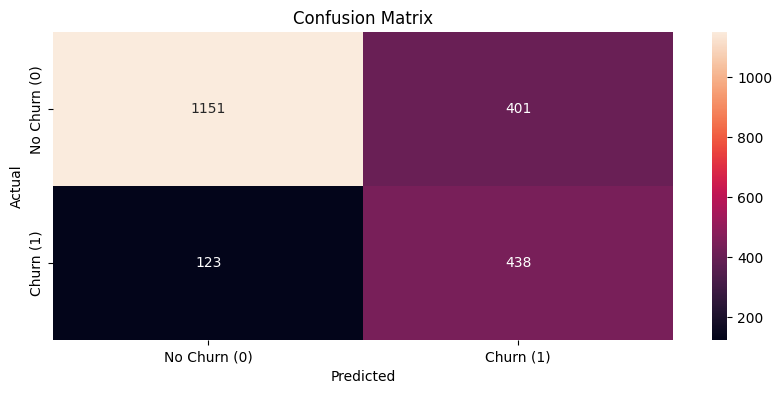

In [ ]:
# Write your code here
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(Y_test, Y_pred)

plt.figure(figsize=(10, 4))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=['No Churn (0)', 'Churn (1)'],
            yticklabels=['No Churn (0)', 'Churn (1)'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

The confusion matrix shows that the model identified 1151 non churners and 438 churners correctly. This results in an overall accuracy of
75% with a recall of 78% for churners. Although the model prodcuces some FPs it sucessfully identifies most customers who are likely to
churn making it good and useful


### IV. Show precision, recall, and F1 score on the test set. (2 pts)

In [ ]:
# Write your code here
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report

precision = precision_score(Y_test, Y_pred)
recall = recall_score(Y_test, Y_pred)
f1 = f1_score(Y_test, Y_pred)

print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1 Score: {f1}")

Precision: 0.5220500595947557
Recall: 0.7807486631016043
F1 Score: 0.6257142857142857


### V. Plot the ROC curve and find the AUC. (2 pts)

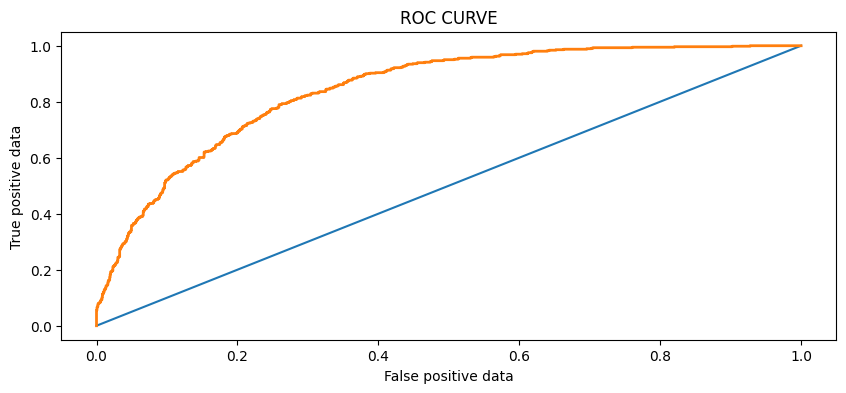

In [ ]:
# Write your code here
from sklearn.metrics import roc_curve, auc

Y_prob = final_pipeline.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(Y_test, Y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(10, 4))
plt.plot([0, 1], [0, 1], label='random guess')
plt.plot(fpr, tpr, lw=2, label="ROC CURVE")
plt.xlabel("False positive data")
plt.ylabel("True positive data")
plt.title("ROC CURVE")
plt.show()

### VI. Plot the precision–recall curve for different thresholds. In a markdown cell, discuss the plot. (3 pts)

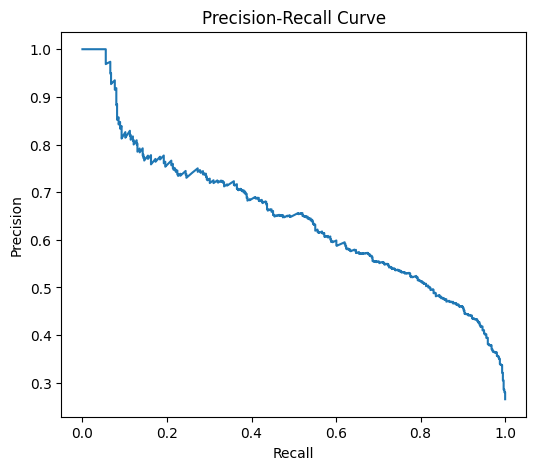

In [ ]:
# Write your code here
from sklearn.metrics import precision_recall_curve

precisions, recalls, thresholds = precision_recall_curve(Y_test, Y_prob)

plt.figure(figsize=(6, 5))
plt.plot(recalls, precisions)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.show()

The preicision recall curve shows the tradeoff between precision and recall as the threshold changes. When preicsion is high the model
catches only a small number of churners. As recall increases, precision gradually decreases because the model identifies more churners
but also makes more false-positive predictions

## E. Softmax Regression [3 pts = 2 + 1]

### I. Short answer (markdown): How is softmax regression related to logistic regression? Discuss two different libraries that can build a softmax regression model. (2 pts)

Softmax regression is an extension of logistic regression that is used for multi-class classification instead of binary classification. While
logistic regression uses the sigmoid function to predict one of two classes, softmax regression uses the softmax function to assign
probabilities across multiple classes. Two common libraries that can build a softmax regression model are scikit-learn, using
LogisticRegression, and TensorFlow/Keras, using a dense output layer with a softmax activation function

### II. Short answer (markdown): If we have 4 classes and 10 features, how many weights plus biases are part of the softmax model? Show your calculation. (1 pt)

Weights = 4(10) = 40 Biases = 4(1) = 4 So total = 44

## F. KNN [25 pts = 4 + 4 + 3 + 2 + 4 + 4 + 4]

*Always use the rebalanced training set for training unless a section says otherwise.*

### I. Train a KNN classifier (k = 10) on the **unbalanced** training set, test it, and show the confusion matrix and classification report. (4 pts)

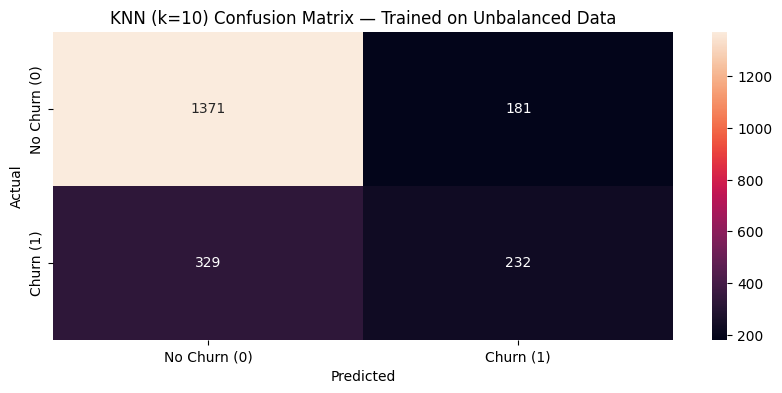

              precision    recall  f1-score   support

    No Churn       0.81      0.88      0.84      1552
       Churn       0.56      0.41      0.48       561

    accuracy                           0.76      2113
   macro avg       0.68      0.65      0.66      2113
weighted avg       0.74      0.76      0.75      2113



In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, classification_report

knn_unbalanced = KNeighborsClassifier(n_neighbors=10)
knn_unbalanced.fit(X_train_unbalanced, Y_train_unbalanced)
Y_pred_knn_unbalanced = knn_unbalanced.predict(X_test)

cm_knn_unbalanced = confusion_matrix(Y_test, Y_pred_knn_unbalanced)

plt.figure(figsize=(10, 4))
sns.heatmap(cm_knn_unbalanced, annot=True, fmt='d',
            xticklabels=['No Churn (0)', 'Churn (1)'],
            yticklabels=['No Churn (0)', 'Churn (1)'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('KNN (k=10) Confusion Matrix — Trained on Unbalanced Data')
plt.show()

print(classification_report(Y_test, Y_pred_knn_unbalanced, target_names=['No Churn', 'Churn']))

### II. Train a KNN classifier (k = 10) on the **rebalanced** training set, test it, and show the confusion matrix and classification report. (4 pts)

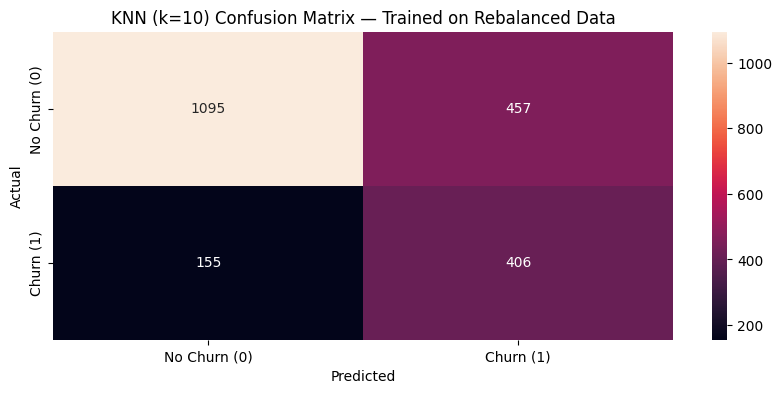

In [ ]:
# Write your code here
knn_balanced = KNeighborsClassifier(n_neighbors=10)
knn_balanced.fit(X_train_balanced, Y_train_balanced)

Y_pred_knn_balanced = knn_balanced.predict(X_test)

cm_knn_balanced = confusion_matrix(Y_test, Y_pred_knn_balanced)

plt.figure(figsize=(10, 4))
sns.heatmap(cm_knn_balanced, annot=True, fmt='d',
            xticklabels=['No Churn (0)', 'Churn (1)'],
            yticklabels=['No Churn (0)', 'Churn (1)'])

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('KNN (k=10) Confusion Matrix — Trained on Rebalanced Data')
plt.show()

### III. Use grid search to tune the following hyper paramerters: number of neighbors (1 to 20), weights (uniform or distance), and metric (Euclidean, Manhattan, or Minkowski). While creating an instance of GridSearchCV, use multiple evaluation metrics such as AUC and accuracy based on the example available at Link to sklearn. Also, some helpful links and codes: https://github.com/oguzhankir/Hyperparameter_Tuning/tree/main/Knn_tuning  and https://www.youtube.com/watch?v=TvB_3jVIHhg  (3 pts) //note that grid search process can take a couple of minutes.

In [ ]:
# Write your code here
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier

parameter_grid = {
    'n_neighbors' : list(range(1, 21)),
    'weights' : ['uniform', 'distance'],
    'metric' : ['euclidean', 'manhattan', 'minkowski']
}

scoring = {
    'AUC': 'roc_auc',
    'Accuracy' : 'accuracy'
}

grid_search = GridSearchCV(
    estimator = KNeighborsClassifier(),
    param_grid=parameter_grid,
    scoring = scoring,
    refit = 'AUC',
    cv = 5,
    n_jobs = -1,
    return_train_score = True
)

grid_search.fit(X_train_balanced, Y_train_balanced)

GridSearchCV(cv=5, estimator=KNeighborsClassifier(), n_jobs=-1,
             param_grid={'metric': ['euclidean', 'manhattan', 'minkowski'],
                         'n_neighbors': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12,
                                         13, 14, 15, 16, 17, 18, 19, 20],
                         'weights': ['uniform', 'distance']},
             refit='AUC', return_train_score=True,
             scoring={'AUC': 'roc_auc', 'Accuracy': 'accuracy'})

### IV. Print the best parameters. (2 pts)

In [ ]:
# Write your code here
print(grid_search.best_params_)

{'metric': 'manhattan', 'n_neighbors': 8, 'weights': 'distance'}


### V. Train a model with the best parameters, test it, and print the confusion matrix, classification report, and the ROC AUC. (4 pts)

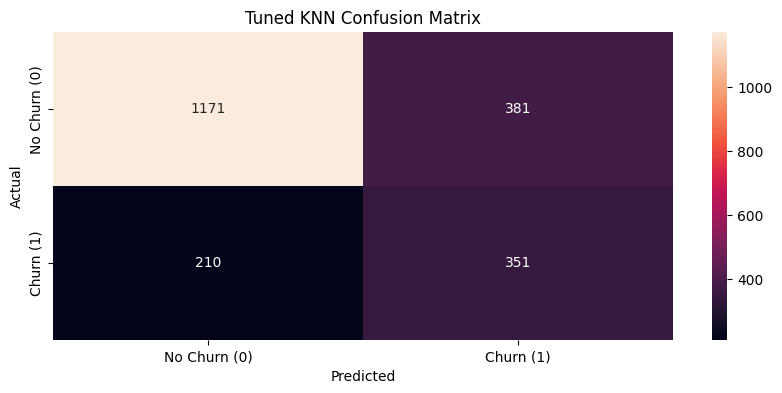

              precision    recall  f1-score   support

    No Churn       0.85      0.75      0.80      1552
       Churn       0.48      0.63      0.54       561

    accuracy                           0.72      2113
   macro avg       0.66      0.69      0.67      2113
weighted avg       0.75      0.72      0.73      2113

ROC AUC: 0.7704


In [ ]:
# Write your code here
from sklearn.metrics import roc_auc_score

best_knn = KNeighborsClassifier(**grid_search.best_params_)
best_knn.fit(X_train_balanced, Y_train_balanced)

Y_pred_best_knn = best_knn.predict(X_test)
Y_prob_best_knn = best_knn.predict_proba(X_test)[:, 1]

cm_best_knn = confusion_matrix(Y_test, Y_pred_best_knn)

plt.figure(figsize=(10, 4))
sns.heatmap(cm_best_knn, annot=True, fmt='d',
            xticklabels=['No Churn (0)', 'Churn (1)'],
            yticklabels=['No Churn (0)', 'Churn (1)'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Tuned KNN Confusion Matrix')
plt.show()

print(classification_report(Y_test, Y_pred_best_knn, target_names=['No Churn', 'Churn']))

roc_auc_best_knn = roc_auc_score(Y_test, Y_prob_best_knn)
print(f"ROC AUC: {roc_auc_best_knn:.4f}")

### VI. Apply PCA with the best KNN setup, test it, and print the confusion matrix, classification report, and the ROC AUC. (4 pts)

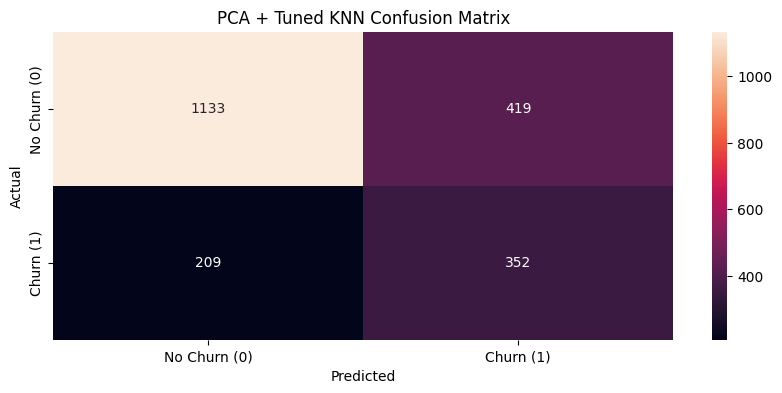

              precision    recall  f1-score   support

    No Churn       0.84      0.73      0.78      1552
       Churn       0.46      0.63      0.53       561

    accuracy                           0.70      2113
   macro avg       0.65      0.68      0.66      2113
weighted avg       0.74      0.70      0.72      2113

ROC AUC: 0.7552


In [ ]:
# Write your code here
from sklearn.pipeline import Pipeline
pca_knn_pipeline = Pipeline(steps = [
    ('pca', PCA(n_components=20)),
    ('knn', KNeighborsClassifier(**grid_search.best_params_))
])
pca_knn_pipeline.fit(X_train_balanced, Y_train_balanced)

Y_pred_pca_knn = pca_knn_pipeline.predict(X_test)
Y_prob_pca_knn = pca_knn_pipeline.predict_proba(X_test)[:, 1]

cm_pca_knn = confusion_matrix(Y_test, Y_pred_pca_knn)

plt.figure(figsize=(10, 4))

sns.heatmap(cm_pca_knn, annot=True, fmt='d',
            xticklabels=['No Churn (0)', 'Churn (1)'],
            yticklabels=['No Churn (0)', 'Churn (1)'])

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('PCA + Tuned KNN Confusion Matrix')
plt.show()

print(classification_report(Y_test, Y_pred_pca_knn, target_names=['No Churn', 'Churn']))
roc_auc_pca_knn = roc_auc_score(Y_test, Y_prob_pca_knn)
print(f"ROC AUC: {roc_auc_pca_knn:.4f}")

### VII. Short answer (markdown): Write a short discussion of the four KNN models above and their differences. (4 pts)

The KNN model trained on the unbalanced data achieved the highest accuracy, but it missed many customers who actually churned
because it favored the majority class. Training on the SMOTE-balanced data greatly improved recall by identifying many more churners,
although it also increased false positives and lowered overall accuracy. Hyperparameter tuning produced a better balance between
precision and recall, making it the strongest overall model. Finally, adding PCA (20 components) had little impact on performance,
suggesting that dimensionality reduction did not provide a significant benefit for KNN on this dataset. Overall, balancing the data had the
greatest positive effect, while tuning provided modest improvements and PCA offered minimal gain.

## G. Naive Bayes [15 pts = 7.5 + 7.5]

### I. Train a GaussianNB model, test it, and print the confusion matrix and classification report. Plot the ROC curve, show the AUC, and count the misclassifications. (7.5 pts)

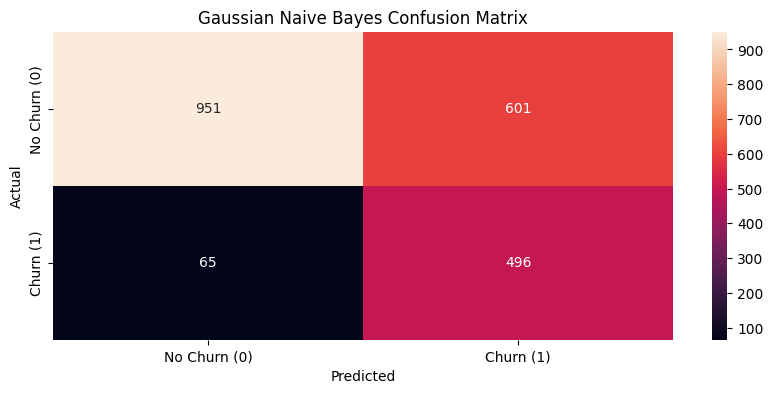

              precision    recall  f1-score   support

    No Churn       0.94      0.61      0.74      1552
       Churn       0.45      0.88      0.60       561

    accuracy                           0.68      2113
   macro avg       0.69      0.75      0.67      2113
weighted avg       0.81      0.68      0.70      2113



In [ ]:
# Write your code here
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc, roc_auc_score

gNB = GaussianNB()
gNB.fit(X_train_balanced, Y_train_balanced)

Y_pred_gNB = gNB.predict(X_test)
Y_prob_gNB = gNB.predict_proba(X_test)[:, 1]

cm_gNB = confusion_matrix(Y_test, Y_pred_gNB)

plt.figure(figsize=(10, 4))
sns.heatmap(cm_gNB, annot=True, fmt='d',
            xticklabels=['No Churn (0)', 'Churn (1)'],
            yticklabels=['No Churn (0)', 'Churn (1)'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Gaussian Naive Bayes Confusion Matrix')
plt.show()

print(classification_report(Y_test, Y_pred_gNB, target_names=['No Churn', 'Churn']))

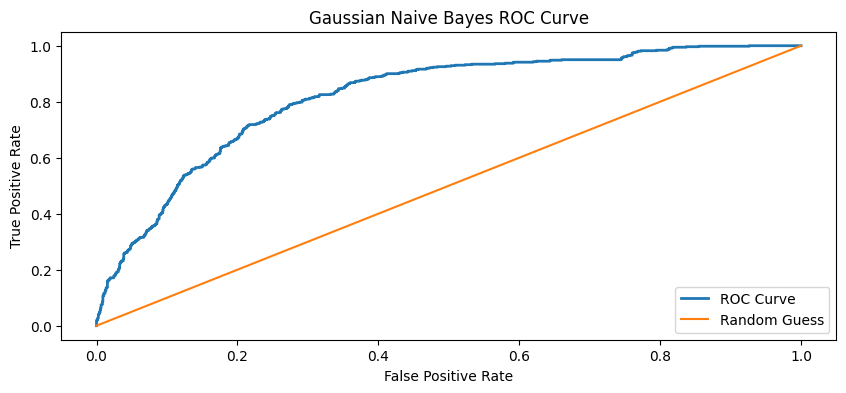

In [ ]:
fpr, tpr, thresholds = roc_curve(Y_test, Y_prob_gNB)
roc_auc_gNB = auc(fpr, tpr)

plt.figure(figsize=(10, 4))
plt.plot(fpr, tpr, lw=2, label='ROC Curve')
plt.plot([0, 1], [0, 1], label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Gaussian Naive Bayes ROC Curve')
plt.legend(loc='lower right')
plt.show()


In [ ]:
missclassifications = (Y_pred_gNB != Y_test).sum()
print((missclassifications / (len(Y_test)) * 100))

31.51916706105064


### II. Train a CategoricalNB model, test it, and print the confusion matrix and classification report. Plot the ROC curve, show the AUC, and count the misclassifications. Note: CategoricalNB expects integer-encoded categorical features. (7.5 pts)

In [ ]:
# Write your code here
from sklearn.naive_bayes import CategoricalNB
from sklearn.preprocessing import KBinsDiscretizer

continuous_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

categorical_cols = [col for col in X_train_balanced.columns if col not in continuous_cols]

discretizer = KBinsDiscretizer(n_bins=5, encode='ordinal', strategy='quantile')

X_train_cat = X_train_balanced.copy()
X_test_cat = X_test.copy()

X_train_cat[continuous_cols] = discretizer.fit_transform(X_train_balanced[continuous_cols])
X_test_cat[continuous_cols] = discretizer.transform(X_test[continuous_cols])

for col in categorical_cols:
    X_train_cat[col] = X_train_cat[col].round().astype(int)
    X_test_cat[col] = X_test_cat[col].round().astype(int)

X_train_cat[continuous_cols] = X_train_cat[continuous_cols].astype(int)
X_test_cat[continuous_cols] = X_test_cat[continuous_cols].astype(int)

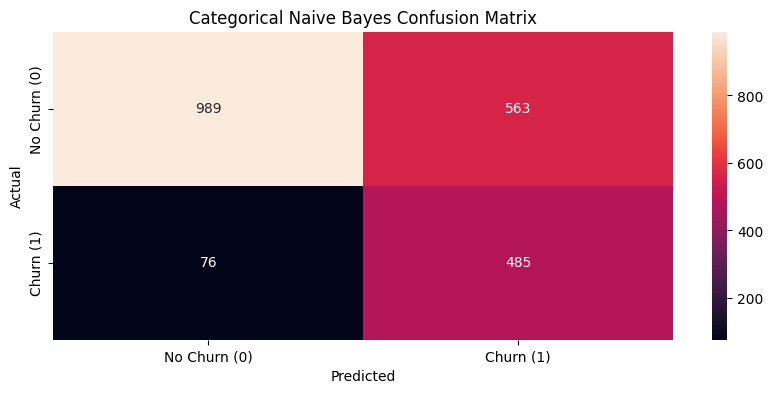

              precision    recall  f1-score   support

    No Churn       0.93      0.64      0.76      1552
       Churn       0.46      0.86      0.60       561

    accuracy                           0.70      2113
   macro avg       0.70      0.75      0.68      2113
weighted avg       0.80      0.70      0.72      2113



In [ ]:
cNB = CategoricalNB()
cNB.fit(X_train_cat, Y_train_balanced)

Y_pred_cNB = cNB.predict(X_test_cat)
Y_prob_cNB = cNB.predict_proba(X_test_cat)[:, 1]

cm_cNB = confusion_matrix(Y_test, Y_pred_cNB)

plt.figure(figsize=(10, 4))
sns.heatmap(cm_cNB, annot= True, fmt = 'd',
            xticklabels=['No Churn (0)', 'Churn (1)'],
            yticklabels=['No Churn (0)', 'Churn (1)'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Categorical Naive Bayes Confusion Matrix')
plt.show()

print(classification_report(Y_test, Y_pred_cNB, target_names=['No Churn', 'Churn']))

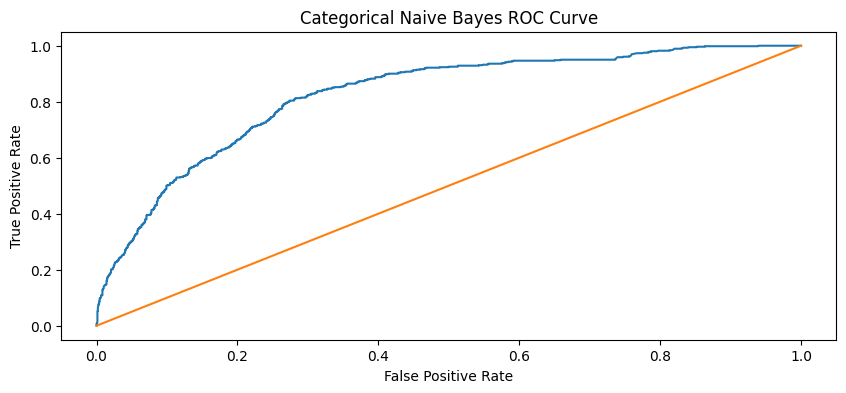

0.8236942269878899


In [ ]:
fpr_cNB, tpr_cNB, thresholds_cNB = roc_curve(Y_test, Y_prob_cNB)
roc_auc_cNB = auc(fpr_cNB, tpr_cNB)

plt.figure(figsize=(10, 4))
plt.plot(fpr_cNB, tpr_cNB, label='ROC Curve')
plt.plot([0, 1], [0, 1], label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Categorical Naive Bayes ROC Curve')
plt.show()

print(roc_auc_cNB)

In [ ]:
missclassification_cNB = (Y_pred_cNB != Y_test).sum()
print((missclassification_cNB)/(len(Y_test)) * 100)

30.241362991008046


## H. Support Vector Machine [20 pts = 10 + 10]

### I. Build an SVC model. Use grid search to tune some parameters and show the best parameters found. (10 pts)

In [ ]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

param_grid = {
    'C' : [0.1, 1, 10, 100],
    'gamma' : ['scale', 'auto', 0.01, 0.1, 1],
    'kernel' : ['rbf', 'linear', 'sigmoid']
}

grid_search_svc = GridSearchCV(
    estimator=SVC(probability=True),
    param_grid = param_grid,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_search_svc.fit(X_train_balanced, Y_train_balanced)

print("Best Parameters")
print(grid_search_svc.best_params_)
print()
print("Best AUC Score")
print(grid_search_svc.best_score_)

Fitting 5 folds for each of 60 candidates, totalling 300 fits


KeyboardInterrupt: 

### II. Test the model and print the confusion matrix and classification report. Plot the ROC curve, show the AUC, and count the misclassifications. (10 pts)

In [ ]:
# Write your code here


## I. Decision Tree [25 pts = 11 + 10 + 4]

### I. Build a decision tree using `DecisionTreeClassifier` on the **unbalanced** training set with entropy as the criterion. Try different `max_depth` values or use grid search. Test it, print the confusion matrix and classification report, plot the ROC curve, show the AUC, count the misclassifications, and show the decision tree (you can simply import tree from sklearn and call tree.plot_tree with your model and the call plt.show. At the beginning of this process, use plt.figure to change the figsize). (11 pts)

In [ ]:
# Write your code here
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
import sklearn.tree as tree

params_grid_decisionTree = {
    'max_depth' : list(range(1, 21))
}

grid_search_decisionTree = GridSearchCV(
    estimator=DecisionTreeClassifier(criterion='entropy', random_state=0),
    param_grid = params_grid_decisionTree,
    scoring='roc_auc',
    cv = 5,
    n_jobs=-1
)

grid_search_decisionTree.fit(X_train_unbalanced, Y_train_unbalanced)

print("Best Parameters")
print(grid_search_decisionTree.best_params_)

print("AUC Score")
print(grid_search_decisionTree.best_score_)

best_tree = grid_search_decisionTree.best_estimator_

Best Parameters
{'max_depth': 4}
AUC Score
0.827677562862139


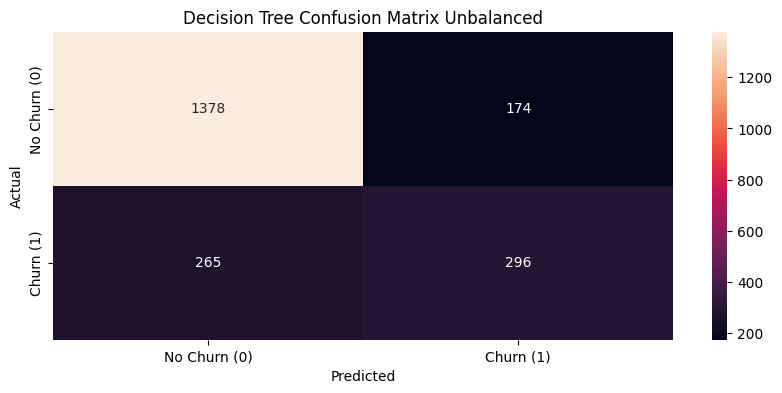

              precision    recall  f1-score   support

    No Churn       0.84      0.89      0.86      1552
       Churn       0.63      0.53      0.57       561

    accuracy                           0.79      2113
   macro avg       0.73      0.71      0.72      2113
weighted avg       0.78      0.79      0.79      2113



In [ ]:
Y_pred_tree = best_tree.predict(X_test)
Y_prob_tree = best_tree.predict_proba(X_test)[:, 1]

cm_tree = confusion_matrix(Y_test, Y_pred_tree)

plt.figure(figsize=(10, 4))
sns.heatmap(cm_tree, annot=True, fmt='d',
            xticklabels=['No Churn (0)', 'Churn (1)'],
            yticklabels=['No Churn (0)', 'Churn (1)'])

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Decision Tree Confusion Matrix Unbalanced')
plt.show()

print(classification_report(Y_test, Y_pred_tree, target_names=['No Churn', 'Churn']))


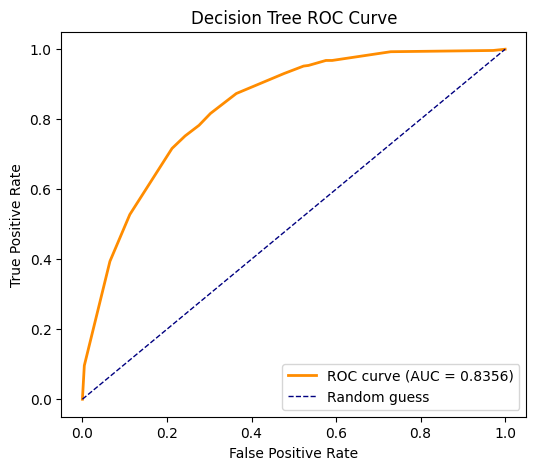

AUC
0.8356166271569547


In [ ]:
fpr_tree, tpr_tree, thresholds_tree = roc_curve(Y_test, Y_prob_tree)
roc_auc_tree = auc(fpr_tree, tpr_tree)

plt.figure(figsize=(6, 5))
plt.plot(fpr_tree, tpr_tree, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc_tree:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--', label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Decision Tree ROC Curve')
plt.legend(loc='lower right')
plt.show()

print("AUC")
print(roc_auc_tree)

In [ ]:
misclassification_tree = (Y_pred_tree != Y_test).sum()
print(misclassification_tree / len(Y_test) * 100)

20.776147657359203


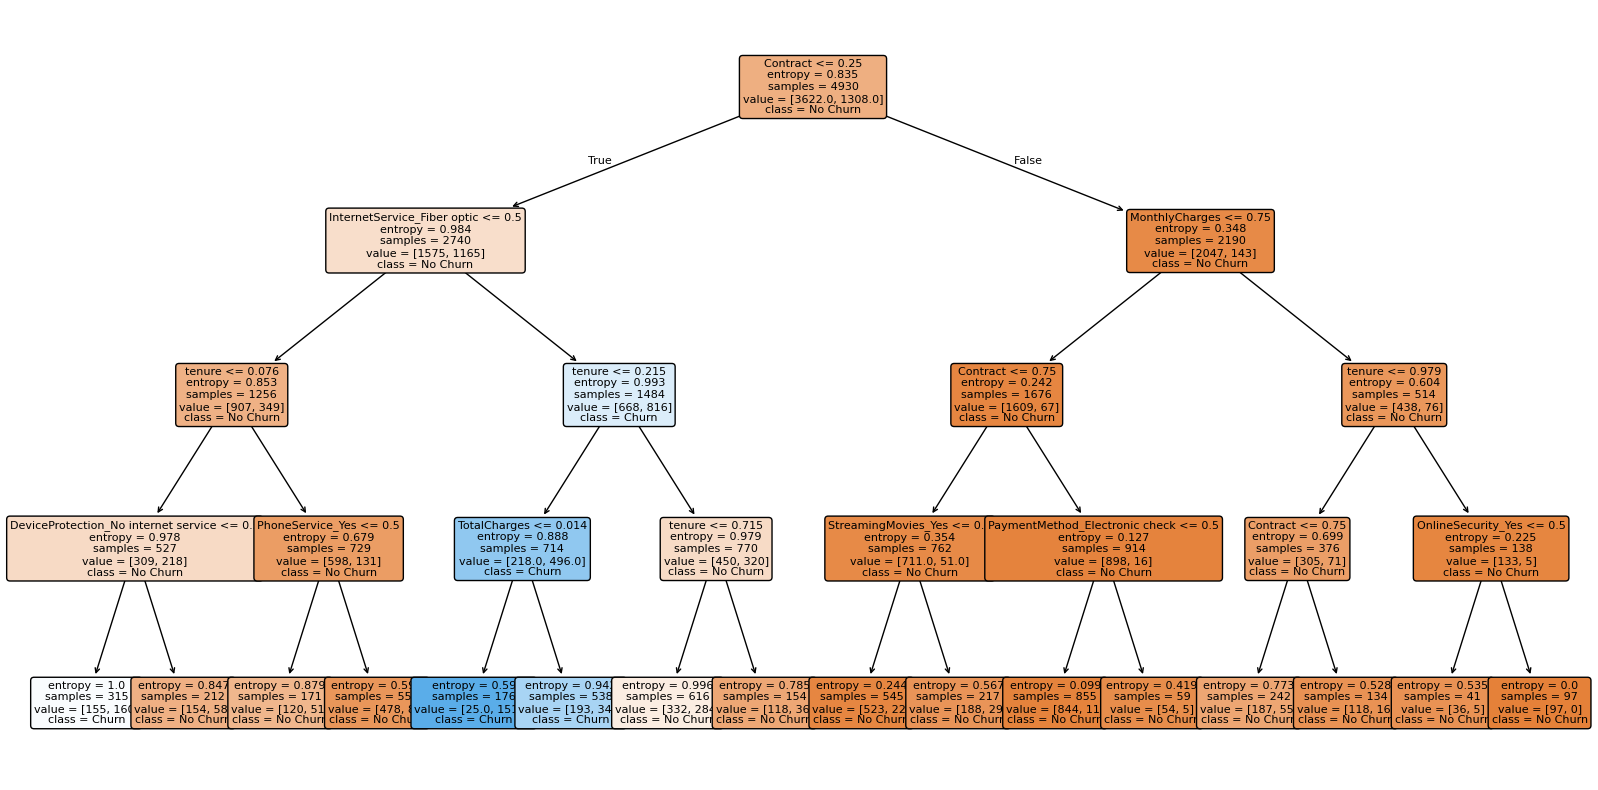

In [ ]:
plt.figure(figsize=(20, 10))
tree.plot_tree(best_tree, feature_names=X_train_unbalanced.columns,
               class_names=['No Churn', 'Churn'], filled=True, rounded=True, fontsize=8)
plt.show()

### II. Perform the same tasks with the **balanced** training set. (10 pts)

In [ ]:
# Write your code here
grid_search_decisionTree_Balanced = GridSearchCV(
    estimator=DecisionTreeClassifier(criterion='entropy', random_state=0),
    param_grid=params_grid_decisionTree,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1
)

grid_search_decisionTree_Balanced.fit(X_train_balanced, Y_train_balanced)

print("Best parameters")
print(grid_search_decisionTree_Balanced.best_params_)

print("AUC")
print(grid_search_decisionTree_Balanced.best_score_)

best_tree_balanced = grid_search_decisionTree_Balanced.best_estimator_

Best parameters
{'max_depth': 6}
AUC
0.8779658145882034


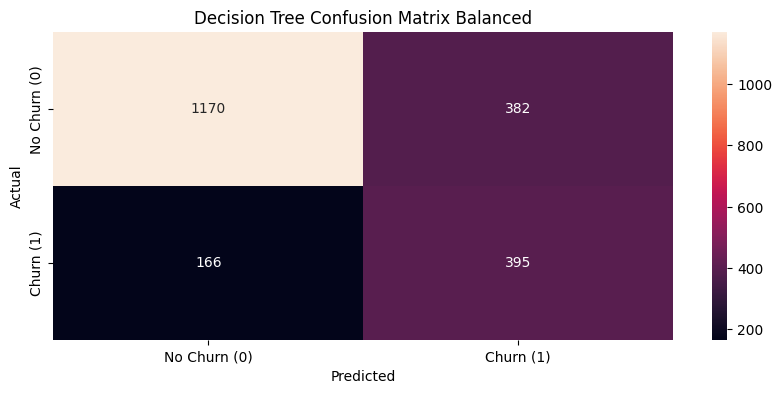

              precision    recall  f1-score   support

    No Churn       0.88      0.75      0.81      1552
       Churn       0.51      0.70      0.59       561

    accuracy                           0.74      2113
   macro avg       0.69      0.73      0.70      2113
weighted avg       0.78      0.74      0.75      2113



In [ ]:
Y_pred_tree_balanced = best_tree_balanced.predict(X_test)
Y_prob_tree_balanced = best_tree_balanced.predict_proba(X_test)[:, 1]

cm_tree_balanced = confusion_matrix(Y_test, Y_pred_tree_balanced)

plt.figure(figsize=(10, 4))
sns.heatmap(cm_tree_balanced, annot=True, fmt='d',
            xticklabels=['No Churn (0)', 'Churn (1)'],
            yticklabels=['No Churn (0)', 'Churn (1)'])

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Decision Tree Confusion Matrix Balanced')
plt.show()

print(classification_report(Y_test, Y_pred_tree_balanced, target_names=['No Churn', 'Churn']))


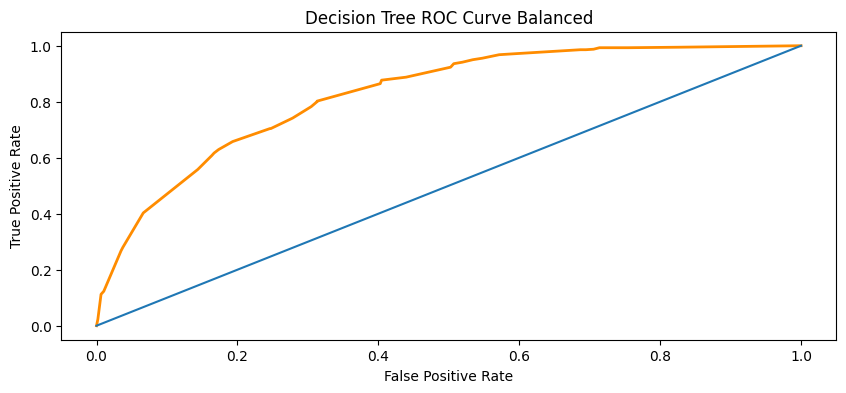

0.8237746246577357


In [ ]:
fpr_tree_bal, tpr_tree_bal, thresholds_tree_bal = roc_curve(Y_test, Y_prob_tree_balanced)
roc_auc_tree_bal = auc(fpr_tree_bal, tpr_tree_bal)

plt.figure(figsize=(10, 4))
plt.plot(fpr_tree_bal, tpr_tree_bal, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc_tree_bal:.4f})')
plt.plot([0, 1], [0, 1], label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Decision Tree ROC Curve Balanced')
plt.show()
print(roc_auc_tree_bal)

In [ ]:
misclassification_tree_balanced = (Y_pred_tree_balanced != Y_test).sum()

print(misclassification_tree_balanced / len(Y_test) * 100)

25.934690014197827


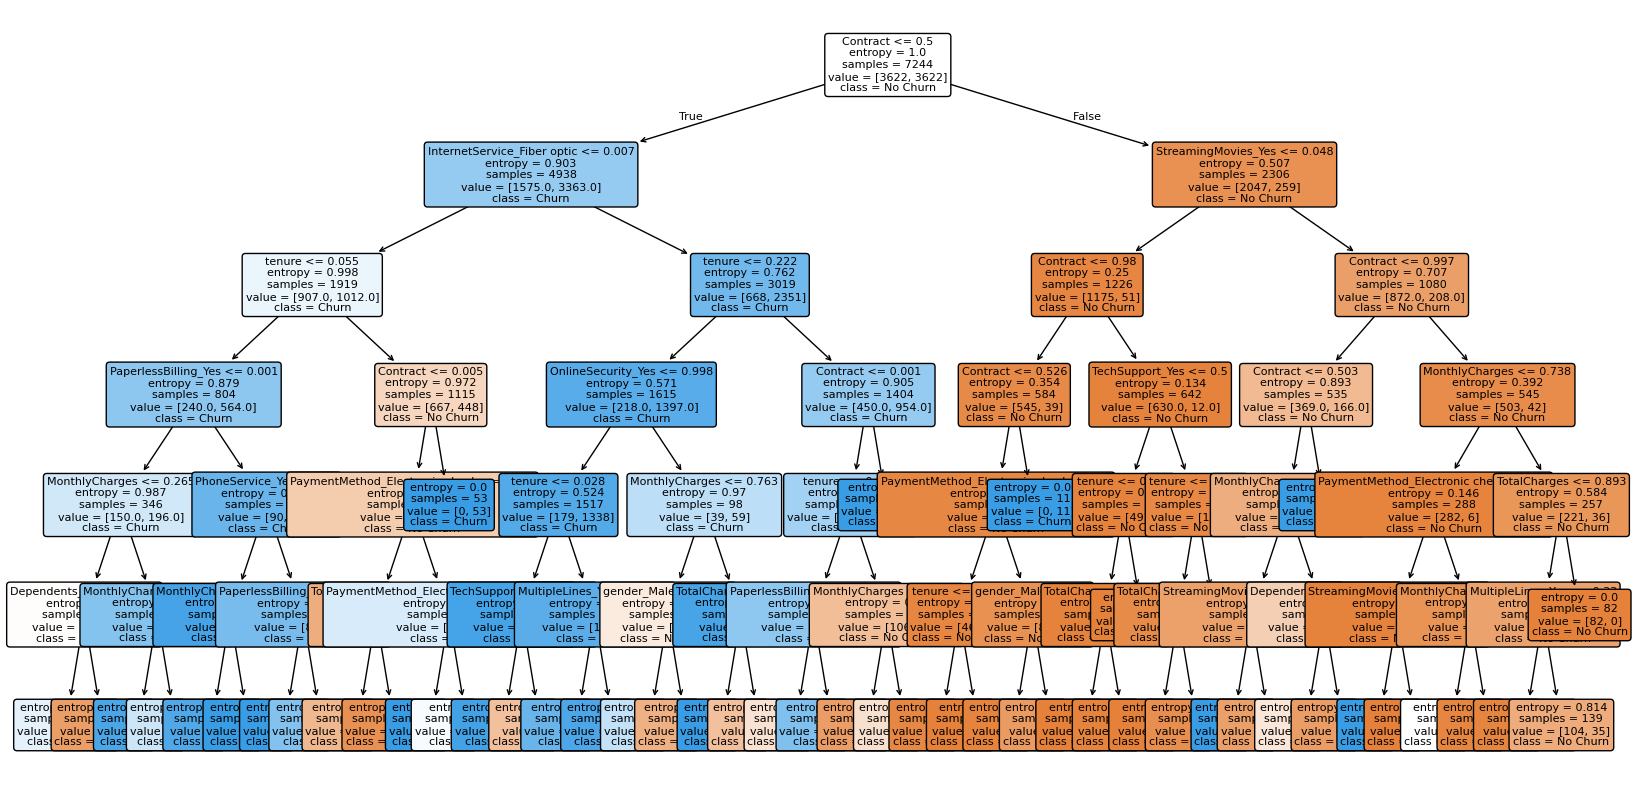

In [ ]:
plt.figure(figsize=(20, 10))
tree.plot_tree(best_tree_balanced, feature_names=X_train_balanced.columns,
               class_names=['No Churn', 'Churn'], filled=True, rounded=True, fontsize=8)
plt.show()

### III. Short answer (markdown): Discuss the difference between the two trees, and discuss part of the tree from section I-II. (4 pts)

The decision tree trained on the unbalanced data is smaller and favors predicting No Churn because most training examples belong to the majority class. The SMOTE-balanced tree is slightly deeper and predicts Churn more often, making it better at identifying customers who are likely to leave. In both trees, Contract is the first split, showing it is the most important feature for predicting churn. For example, in the first tree, customers on month-to-month contracts are further split by InternetService and tenure, indicating that contract type, internet service, and how long a customer has been with the company are key factors in predicting churn.

## J. Random Forest [15 pts = 8 + 1 + 6]

### I. Use grid search to tune `max_depth`, `min_samples_leaf`, and `n_estimators`. (helpful link:https://www.analyticsvidhya.com/blog/2021/06/understanding-random-forest/) [it may take few minutes (8 pts)

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

randomForest = RandomForestClassifier(random_state=42, n_jobs=-1)

params = {
    'max_depth': [2, 3, 5, 10, 20],
    'min_samples_leaf': [5, 10, 20, 50, 100, 200],
    'n_estimators': [10, 25, 30, 50, 100, 200]
}

# Instantiate the grid search model
grid_search_randomForest = GridSearchCV(
    estimator=randomForest,
    param_grid=params,
    cv=4,
    n_jobs=-1,
    verbose=1,
    scoring="accuracy"
)

grid_search_randomForest.fit(X_train_balanced, Y_train_balanced)

Fitting 4 folds for each of 180 candidates, totalling 720 fits


GridSearchCV(cv=4, estimator=RandomForestClassifier(n_jobs=-1, random_state=42),
             n_jobs=-1,
             param_grid={'max_depth': [2, 3, 5, 10, 20],
                         'min_samples_leaf': [5, 10, 20, 50, 100, 200],
                         'n_estimators': [10, 25, 30, 50, 100, 200]},
             scoring='accuracy', verbose=1)

### II. Print the best estimator. (1 pt)

In [ ]:
# Write your code here
print(grid_search_randomForest.best_estimator_)

RandomForestClassifier(max_depth=20, min_samples_leaf=5, n_estimators=200,
                       n_jobs=-1, random_state=42)


### III. Train the model, test it, print the confusion matrix and classification report, plot the ROC curve, show the AUC, and count the misclassifications. (6 pts)

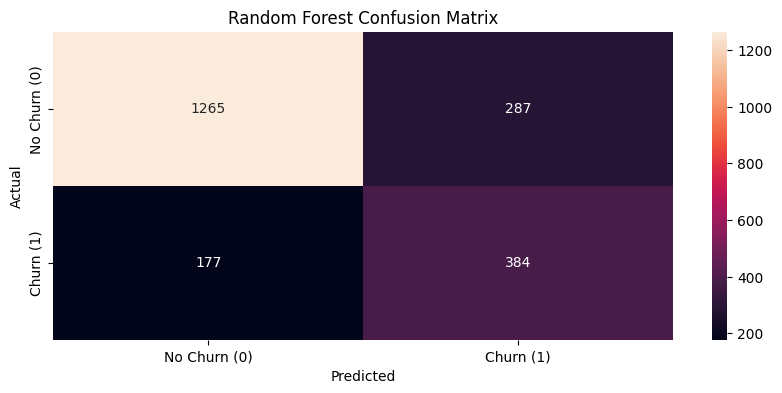

              precision    recall  f1-score   support

    No Churn       0.88      0.82      0.85      1552
       Churn       0.57      0.68      0.62       561

    accuracy                           0.78      2113
   macro avg       0.72      0.75      0.73      2113
weighted avg       0.80      0.78      0.79      2113



In [ ]:
randomForest_best = grid_search_randomForest.best_estimator_
#in hindsight I should've just created this to print the best estimator

randomForest_best.fit(X_train_balanced, Y_train_balanced)

Y_pred_randomForest = randomForest_best.predict(X_test)
Y_prob_randomForest = randomForest_best.predict_proba(X_test)[:, 1]

cm_randomForest = confusion_matrix(Y_test, Y_pred_randomForest)

plt.figure(figsize=(10, 4))
sns.heatmap(cm_randomForest, annot=True, fmt='d',
            xticklabels=['No Churn (0)', 'Churn (1)'],
            yticklabels=['No Churn (0)', 'Churn (1)'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title("Random Forest Confusion Matrix")
plt.show()

print(classification_report(Y_test, Y_pred_randomForest, target_names=['No Churn', 'Churn']))

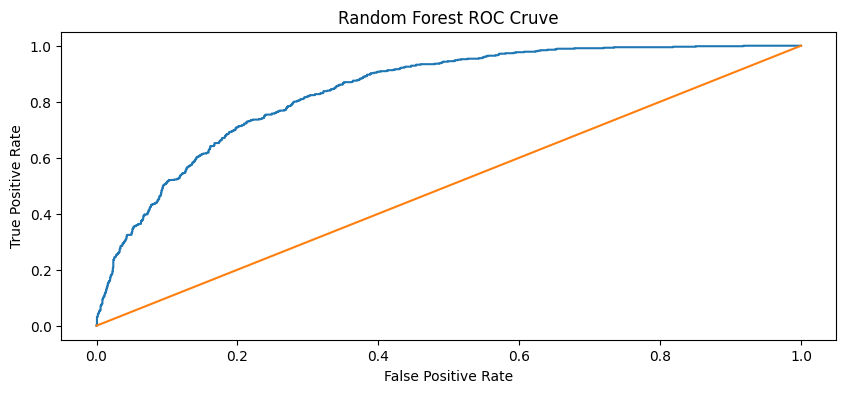

0.8403112768068802


In [ ]:
fpr_rf, tpr_rf, thresholds_rf = roc_curve(Y_test, Y_prob_randomForest)
roc_auc_rf = auc(fpr_rf, tpr_rf)

plt.figure(figsize=(10, 4))
plt.plot(fpr_rf, tpr_rf, label = 'ROC CURVE')
plt.plot([0, 1], [0, 1], label='random guessing')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title("Random Forest ROC Cruve")
plt.show()

print(roc_auc_rf)

In [ ]:
misclassification_randomForest = (Y_pred_randomForest != Y_test).sum()
print(misclassification_randomForest / len(Y_test) * 100)

21.959299574065312


## K. Boosting Algorithms [10 pts = 5 + 5]

### I. Train an AdaBoostClassifier with manual or grid-search parameters. Test it, print the confusion matrix and classification report, plot the ROC curve, show the AUC, and count the misclassifications. (5 pts)

In [ ]:
# Write your code here
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

param_grid_ada = {
    'n_estimators' : [50, 100, 200],
    'learning_rate' : [0.01, 0.1, 0.5, 1.0]
}

base_tree = DecisionTreeClassifier(max_depth = 1, random_state = 0)

grid_search_ada = GridSearchCV(
    estimator = AdaBoostClassifier(estimator=base_tree, random_state=0),
    param_grid=param_grid_ada,
    scoring='roc_auc',
    cv = 5,
    n_jobs = -1,
    verbose = 1
)

grid_search_ada.fit(X_train_balanced, Y_train_balanced)

print("Best Parameters")
print(grid_search_ada.best_params_)
print("Best AUC Score")
print(grid_search_ada.best_score_)

#learning from last time
ada_best = grid_search_ada.best_estimator_


Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best Parameters
{'learning_rate': 1.0, 'n_estimators': 200}
Best AUC Score
0.8979153769357804


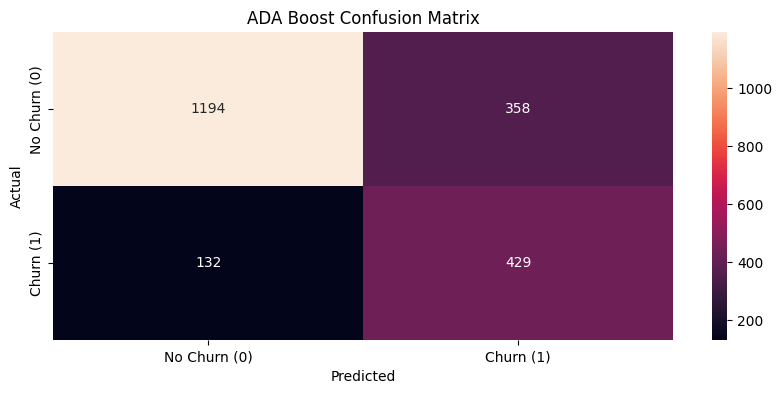

              precision    recall  f1-score   support

    No Churn       0.90      0.77      0.83      1552
       Churn       0.55      0.76      0.64       561

    accuracy                           0.77      2113
   macro avg       0.72      0.77      0.73      2113
weighted avg       0.81      0.77      0.78      2113



In [ ]:
Y_pred_ada = ada_best.predict(X_test)
Y_prob_ada = ada_best.predict_proba(X_test)[:, 1]

cm_ada = confusion_matrix(Y_test, Y_pred_ada)

plt.figure(figsize=(10, 4))
sns.heatmap(cm_ada, annot=True, fmt='d',
            xticklabels=['No Churn (0)', 'Churn (1)'],
            yticklabels=['No Churn (0)', 'Churn (1)'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('ADA Boost Confusion Matrix')
plt.show()

print(classification_report(Y_test, Y_pred_ada, target_names=['No Churn', 'Churn']))

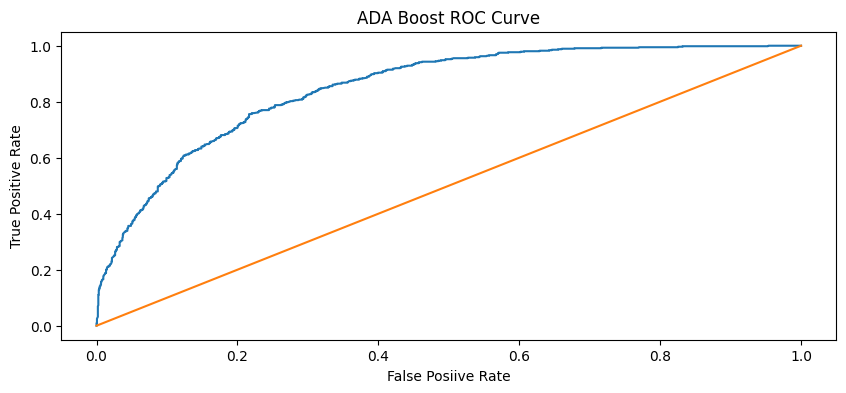

0.849414015840638


In [ ]:
fpr_ada, tpr_ada, thresholds_ada = roc_curve(Y_test, Y_prob_ada)
roc_auc_ada = auc(fpr_ada, tpr_ada)

plt.figure(figsize=(10, 4))
plt.plot(fpr_ada, tpr_ada, label='ROC CURVE')
plt.plot([0, 1], [0, 1], label='Random Guess')
plt.xlabel("False Posiive Rate")
plt.ylabel("True Positive Rate")
plt.title("ADA Boost ROC Curve")
plt.show()

print(roc_auc_ada)

In [ ]:
misclassifications_ada = (Y_pred_ada != Y_test).sum()
print(misclassifications_ada / len(Y_test) * 100)

23.18977756743966


### II. Do the same for a GradientBoostingClassifier. (5 pts)
Helpful links:
https://www.analyticsvidhya.com/blog/2015/11/quick-introduction-boosting-algorithms-machine-learning/#:~:text=Types%20of%20Boosting%20Algorithms&text=AdaBoost%20(Adaptive%20Boosting),XGBoost

Another link: https://www.machinelearningplus.com/machine-learning/an-introduction-to-gradient-boosting-decision-trees/

In [ ]:
# Write your code here
from sklearn.ensemble import GradientBoostingClassifier

param_grid_gradient = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1, 0.5, 1.0],
    'max_depth':[1, 2, 3]
}

grid_search_gradient = GridSearchCV(
    estimator = GradientBoostingClassifier(random_state=0),
    param_grid=param_grid_gradient,
    scoring='roc_auc',
    cv = 5,
    n_jobs = -1,
    verbose = 1
)

grid_search_gradient.fit(X_train_balanced, Y_train_balanced)
print("Best Parameters")
print(grid_search_gradient.best_params_)
print("Best AUC Score")
print(grid_search_gradient.best_score_)





Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best Parameters
{'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200}
Best AUC Score
0.9317513604275056


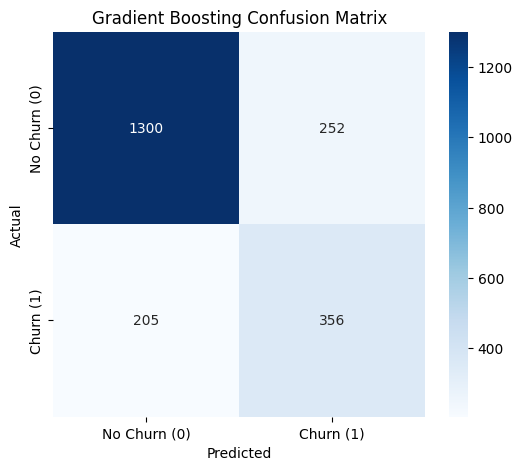

              precision    recall  f1-score   support

    No Churn       0.86      0.84      0.85      1552
       Churn       0.59      0.63      0.61       561

    accuracy                           0.78      2113
   macro avg       0.72      0.74      0.73      2113
weighted avg       0.79      0.78      0.79      2113



In [ ]:

gradient_best = grid_search_gradient.best_estimator_
Y_pred_gb = gradient_best.predict(X_test)
Y_prob_gb = gradient_best.predict_proba(X_test)[:, 1]

cm_gb = confusion_matrix(Y_test, Y_pred_gb)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_gb, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Churn (0)', 'Churn (1)'],
            yticklabels=['No Churn (0)', 'Churn (1)'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Gradient Boosting Confusion Matrix')
plt.show()

print(classification_report(Y_test, Y_pred_gb, target_names=['No Churn', 'Churn']))

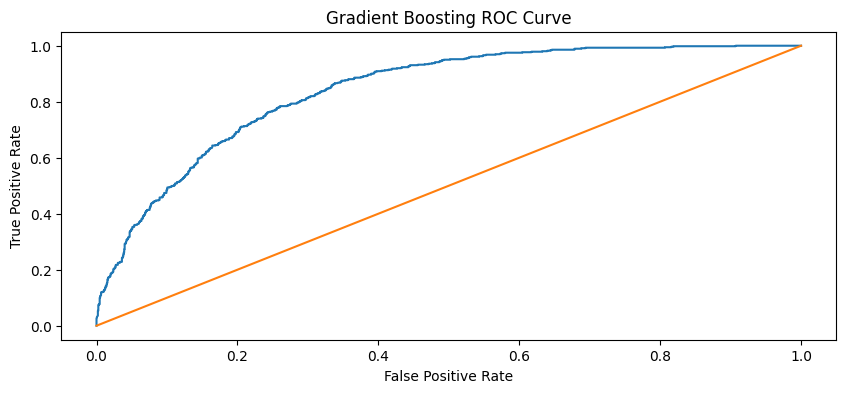

0.839563578477314


In [ ]:
fpr_gradient, tpr_gradient, thresholds_gradient = roc_curve(Y_test, Y_prob_gb)
roc_auc_gradient = auc(fpr_gradient, tpr_gradient)

plt.figure(figsize=(10, 4))
plt.plot(fpr_gradient, tpr_gradient, label='ROC CURVE')
plt.plot([0, 1], [0, 1], label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Gradient Boosting ROC Curve')
plt.show()

print(roc_auc_gradient)

In [ ]:
misclassifications_gradient = (Y_pred_gb != Y_test).sum()
print(misclassifications_gradient / len(Y_test) * 100)

21.6280170373876


## L. Final Discussion [10 pts]

### I. In a markdown cell, briefly discuss your findings, including which model is most suitable for this churn scenario and which metrics you based that on. Discuss performance on both the churn and non-churn classes and the effect of balanced versus unbalanced data. Then describe possible future work. (10 pts)

The model with the lowest misclassification rate was the unbalanced Decision Tree at 20.77%. However, this result can be misleading because the dataset contains more non-churn customers than churn customers. Models trained on unbalanced data often achieve higher accuracy by correctly predicting the majority class while missing a larger number of actual churners. Models trained on balanced (SMOTE) data had slightly higher misclassification rates, but they were designed to treat both classes more equally. Among the balanced models, Gradient Boosting achieved the best performance with a misclassification rate of 21.62%, followed closely by Random Forest at 21.96%. Both models outperformed AdaBoost, the balanced Decision Tree, and the Naive Bayes models.

For a customer churn prediction problem, identifying customers who are likely to churn is generally more important than maximizing overall accuracy. A false negative results in a customer being lost, while a false positive only results in an unnecessary retention effort. Based on the results, Gradient Boosting is the strongest overall model because it achieved the lowest misclassification rate among the balanced models while also producing one of the strongest ROC curves. The comparison between balanced and unbalanced training showed a consistent tradeoff: unbalanced data improved overall accuracy, while balanced data improved the model's ability to identify churners. Future improvements could include threshold tuning, cost-sensitive learning, additional feature engineering